# Building makemore Part 3: Activations & Gradients, BatchNorm

## Introduction

In Part 2 we built an MLP language model following the Bengio et al. (2003) paper. It worked, but we were sloppy about initialization and training details. In this lecture, we go **under the hood** to understand:

1. **Why initialization matters** — bad initial weights cause the network to be confidently wrong or have "dead" neurons from the start
2. **Activation statistics** — how values flow through the network (forward pass) and how gradients flow back (backward pass)
3. **Kaiming initialization** — a principled way to set initial weights so activations neither explode nor vanish
4. **Batch Normalization** — a technique that normalizes activations during training, making networks much easier to train
5. **Diagnostic visualizations** — tools to inspect your network's health and catch problems early

This is a crucial lecture for building intuition about **why deep networks are hard to train** and the key techniques that make them work.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

## Starter Code: Dataset and Setup

Same setup as Part 2 — load names, build character mappings, create train/val/test splits with a context window of 3 characters. We'll skip explaining this since it's identical to last time.

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


## The MLP Revisited: Fixing Initialization Problems

This is the heart of the lecture. We start with the same MLP from Part 2, but now we carefully examine and fix the initialization.

### Problem 1: Fixing the Initial Loss (Softmax Confidently Wrong)

When weights are randomly initialized with large values, the network produces large logits, which after softmax become very confident (peaked) probability distributions. But at initialization the network knows nothing — so it's **confidently wrong**, leading to a very high initial loss.

**The fix:** Initialize the output layer weights (`W2`) very small (`* 0.01`) and biases to zero (`* 0`). This makes initial logits close to zero, so softmax outputs a roughly **uniform distribution** (~1/27 for each character). The initial loss should be close to `-log(1/27) = 3.30` — the entropy of a uniform distribution.

### Problem 2: Fixing Saturated `tanh` Neurons

If the pre-activation values going into `tanh` are too large (very positive or very negative), `tanh` saturates at +1 or -1. In these flat regions, the **gradient is nearly zero**, so the neuron barely learns — it's essentially "dead."

**How to diagnose:** Check what percentage of `tanh` outputs have absolute value > 0.97. If it's high (e.g., 90%+), most neurons are saturated.

**The fix:** Scale down `W1` so that pre-activations are in a reasonable range (roughly standard normal).

### Problem 3: Kaiming Initialization

Instead of hand-tuning the scale, we use a **principled formula** from the paper by He et al. (2015):

```
W1 = torch.randn(...) * (5/3) / sqrt(fan_in)
```

**The idea:** If inputs have unit variance, after multiplying by a weight matrix of shape `(fan_in, fan_out)`, the output variance gets multiplied by `fan_in`. Dividing by `sqrt(fan_in)` keeps the variance at 1. The `5/3` factor compensates for `tanh` squashing the variance (since `tanh` has gain ~5/3 for standard normal inputs).

This ensures activations neither **explode** (grow exponentially through layers) nor **vanish** (shrink to zero), which is critical for deep networks.

### Batch Normalization (Ioffe & Szegedy, 2015)

Even with good initialization, activations can drift during training. **BatchNorm** fixes this by normalizing the pre-activations **at every layer, at every training step**:

```python
# For each neuron across the batch:
mean_i = hpreact.mean(0, keepdim=True)    # mean across the batch (dim 0)
std_i  = hpreact.std(0, keepdim=True)     # std across the batch (dim 0)
hpreact = bngain * (hpreact - mean_i) / std_i + bnbias
```

**What it does:**
1. **Center and scale** — Subtract the batch mean, divide by the batch std. After this, each neuron's activations have mean=0, std=1 across the batch.
2. **Learnable affine transform** — `bngain` (gamma) and `bnbias` (beta) let the network undo the normalization if it wants to. These are learned parameters.

**Running statistics:** During training, we track exponential moving averages of mean and std (`bnmean_running`, `bnstd_running`). At inference time, we use these running stats instead of batch stats (because at inference we might process a single example, and a batch of 1 has meaningless statistics).

**Why it works:** BatchNorm keeps pre-activations in a well-behaved range regardless of what earlier layers do. This makes training faster, more stable, and less sensitive to initialization and learning rate choices.

**Important caveat:** BatchNorm couples examples within a minibatch — the output for one example depends on what other examples are in the batch. This is conceptually "weird" and has subtle implications we'll revisit later.

In [6]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5) #* 0.2
#b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

# BatchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


## Training Loop

The same training loop as Part 2, but with BatchNorm integrated into the forward pass. Note the key additions:
- The **BatchNorm block** between the linear layer and `tanh` — it normalizes `hpreact` using batch statistics
- The **running mean/std update** with momentum 0.999 — keeps an exponential moving average for inference
- The bias `b1` is **removed** from the linear layer — BatchNorm already adds a bias (`bnbias`), so having both is redundant

In [7]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
  # BatchNorm layer
  # -------------------------------------------------------------
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  

      0/ 200000: 3.3239
  10000/ 200000: 2.0322
  20000/ 200000: 2.5675
  30000/ 200000: 2.0125
  40000/ 200000: 2.2446
  50000/ 200000: 1.8897
  60000/ 200000: 2.0785
  70000/ 200000: 2.3681
  80000/ 200000: 2.2918
  90000/ 200000: 2.0238
 100000/ 200000: 2.3673
 110000/ 200000: 2.3132
 120000/ 200000: 1.6414
 130000/ 200000: 1.9311
 140000/ 200000: 2.2231
 150000/ 200000: 2.0027
 160000/ 200000: 2.0997
 170000/ 200000: 2.4949
 180000/ 200000: 2.0199
 190000/ 200000: 2.1707


## Training Loss Curve

Plot of `log10(loss)` over training steps. The curve should decrease smoothly, showing the model is learning.

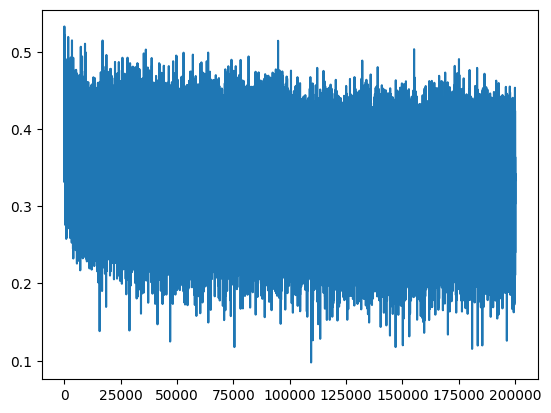

In [8]:
plt.plot(lossi)

## Calibrating Batch Norm After Training

The running mean/std accumulated during training (via exponential moving average) might not be perfectly accurate. Here we do a **final calibration pass**: run the entire training set through the network once and compute the exact mean and std.

This gives us the most accurate batch norm statistics for inference. (In practice, the running averages are usually good enough, but this is a useful technique to know about.)

In [9]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 # + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)


## Evaluating Train and Validation Loss

We evaluate the model on the full training and validation sets. At inference time, we use the **running statistics** (`bnmean_running`, `bnstd_running`) instead of batch statistics — this is crucial because:
1. At inference we might have a single example (batch size = 1)
2. We want deterministic outputs — the same input should always produce the same output

The `@torch.no_grad()` decorator disables gradient computation, saving memory and computation during evaluation.

In [10]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 # + b1
  #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0674145221710205
val 2.1056840419769287


## loss log

### original:
train 2.1245384216308594
val   2.168196439743042

### fix softmax confidently wrong:
train 2.07
val   2.13

### fix tanh layer too saturated at init:
train 2.0355966091156006
val   2.1026785373687744

### use semi-principled "kaiming init" instead of hacky init:
train 2.0376641750335693
val   2.106989622116089

### add batch norm layer
train 2.0668270587921143
val 2.104844808578491


## Part 2: PyTorch-ifying the Code

Everything above used raw tensors and manual operations. Now we refactor into **classes** that mirror PyTorch's `nn.Module` API. This is how real PyTorch code is organized.

We create three classes:
- **`Linear`** — A fully connected layer: `y = x @ W + b`. Initializes weights with Kaiming init (`/ fan_in**0.5`).
- **`BatchNorm1d`** — Normalizes activations across the batch dimension. Tracks running mean/var for inference. Has learnable `gamma` (gain) and `beta` (bias).
- **`Tanh`** — The tanh non-linearity. Stores its output for diagnostic visualization.

Each class has:
- `__call__` — the forward pass (called like a function)
- `parameters()` — returns the learnable parameters (for the optimizer)

### The Deeper Network

With these building blocks, we can easily define a **6-layer deep** network by stacking `[Linear, BatchNorm, Tanh]` blocks:

```
Input (30) -> Linear (100) -> BN -> Tanh ->
              Linear (100) -> BN -> Tanh ->
              Linear (100) -> BN -> Tanh ->
              Linear (100) -> BN -> Tanh ->
              Linear (100) -> BN -> Tanh ->
              Linear (27)  -> BN -> Output
```

Without BatchNorm, training this 6-layer network would be very difficult — gradients would vanish or explode. With BatchNorm, it trains reliably.

**Note on the output layer:** We scale `layers[-1].gamma *= 0.1` to make the network less confident initially (same idea as `W2 *= 0.01` before). Also, `bias=False` on Linear layers before BatchNorm since BN already has a bias term (`beta`).

In [11]:
# SUMMARY + PYTORCHIFYING -----------

In [12]:
# Let's train a deeper network
# The classes we create here are the same API as nn.Module in PyTorch

class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd),            generator=g)
layers = [
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
]
# layers = [
#   Linear(n_embd * block_size, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, vocab_size),
# ]

with torch.no_grad():
  # last layer: make less confident
  layers[-1].gamma *= 0.1
  #layers[-1].weight *= 0.1
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 1.0 #5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

47024


## Training the Deeper Network

Same training loop, but now using the modular layer classes. The forward pass is clean:
```python
for layer in layers:
    x = layer(x)
```

**Diagnostic additions:**
- `layer.out.retain_grad()` — tells PyTorch to keep gradients for intermediate activations (normally only leaf parameters keep gradients). This lets us inspect gradient flow through the network.
- `ud` (update-to-data ratio) — tracks `(lr * grad).std() / data.std()` for each parameter. This ratio tells us how much each update changes the parameter relative to its magnitude.

*Note: `break` at 1000 steps for debugging — remove this for full training.*

In [13]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
  
  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  if i >= 1000:
    break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.2870


## Visualization 1: Forward Pass Activation Statistics

For each `Tanh` layer, we plot the **histogram of activation values**.

**What to look for:**
- **Healthy:** A roughly Gaussian distribution centered around 0, with std around 0.65 (the std of `tanh(N(0,1))`)
- **Saturated (bad):** Values piled up at -1 and +1. This means `tanh` is in its flat region, gradients are near zero, and the layer is barely learning. The "saturated %" metric quantifies this.
- **Collapsed (bad):** All values near 0. The layer is not using its full dynamic range.

**What causes saturation:** If the pre-activation values (inputs to `tanh`) are too large in magnitude, `tanh` squashes them to +/-1. This happens when weights are initialized too large, or when activations grow as they pass through multiple layers.

**The fix:** Proper initialization (Kaiming) and/or BatchNorm keep pre-activations in a reasonable range across all layers.

layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 2.78%
layer 5 (      Tanh): mean +0.00, std 0.64, saturated: 2.56%
layer 8 (      Tanh): mean -0.00, std 0.65, saturated: 2.25%
layer 11 (      Tanh): mean +0.00, std 0.65, saturated: 1.69%
layer 14 (      Tanh): mean +0.00, std 0.65, saturated: 1.88%


C:\Users\MSI\AppData\Local\Temp\ipykernel_24628\1397477801.py:7: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))


Text(0.5, 1.0, 'activation distribution')

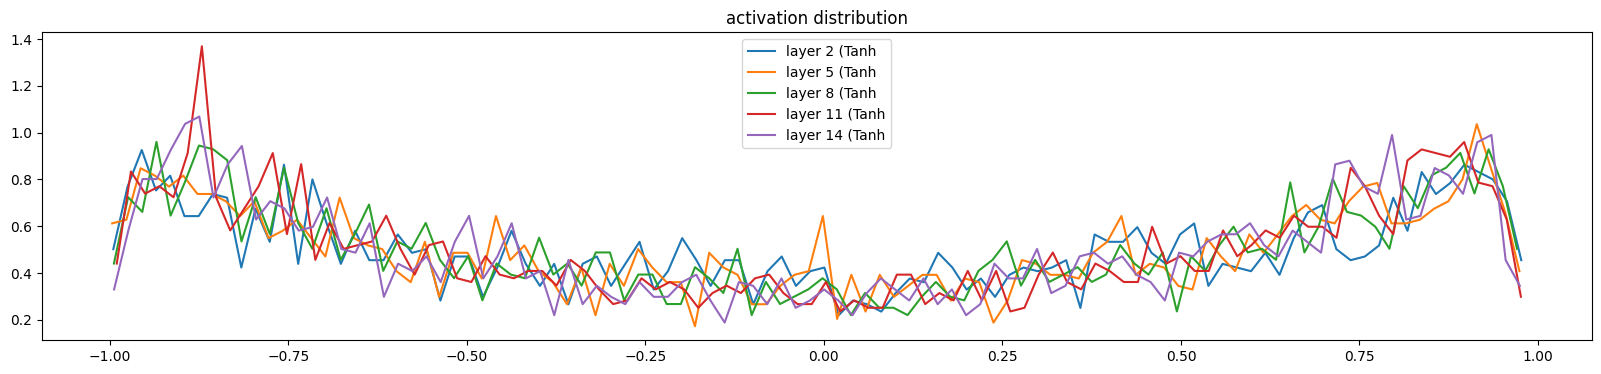

In [14]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

## Visualization 2: Backward Pass Gradient Statistics

For each `Tanh` layer, we plot the histogram of **gradients** flowing backward through the network.

**What to look for:**
- **Healthy:** All layers have similar gradient distributions (similar std). This means the learning signal propagates evenly through the network.
- **Vanishing gradients (bad):** Gradient std decreases as we go deeper (earlier layers). These layers learn much more slowly.
- **Exploding gradients (bad):** Gradient std increases as we go deeper. Training becomes unstable.

In a network with **no non-linearities** (purely linear), you'd see either perfect preservation or exponential growth/decay depending on the weight scale. `tanh` acts as a "gain" that can amplify or dampen the gradient flow — Kaiming init tries to set the gain just right.

**The fully linear case:** If we remove all non-linearities, stacking N linear layers is equivalent to one linear layer (`W1 @ W2 @ ... @ Wn` is just one matrix). Non-linearities are what make depth useful.

layer 2 (      Tanh): mean -0.000000, std 2.640702e-03
layer 5 (      Tanh): mean +0.000000, std 2.245584e-03
layer 8 (      Tanh): mean -0.000000, std 2.045742e-03
layer 11 (      Tanh): mean +0.000000, std 1.983133e-03
layer 14 (      Tanh): mean -0.000000, std 1.952382e-03


Text(0.5, 1.0, 'gradient distribution')

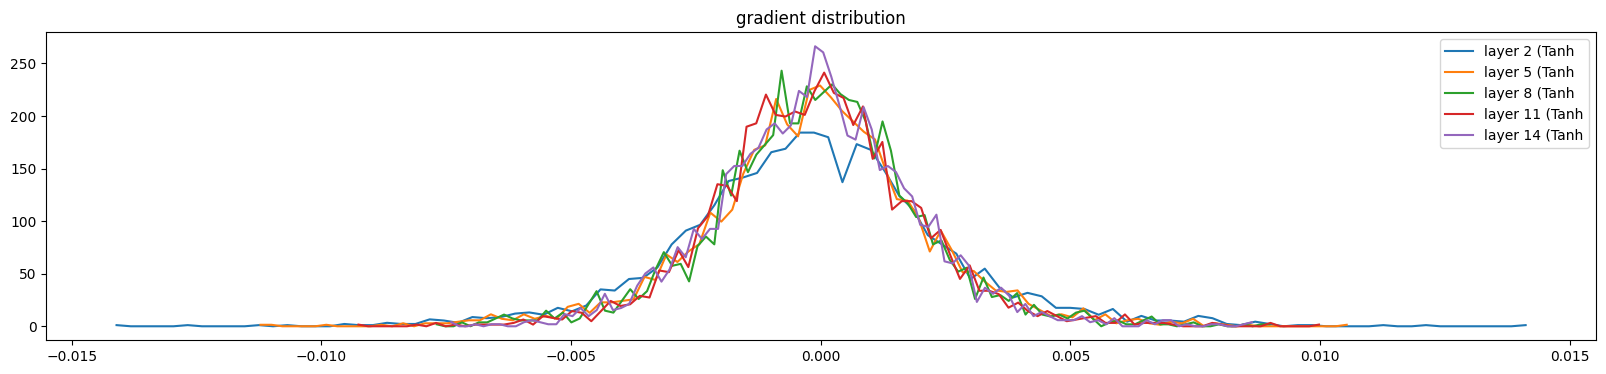

In [15]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

## Visualization 3: Parameter Gradient Statistics

For each weight matrix, we plot the gradient distribution and compute the **grad-to-data ratio** (`grad.std() / weight.std()`).

**What to look for:**
- All weight matrices should have similar gradient magnitudes
- If some weights have much smaller gradients, those layers are learning more slowly
- Very large ratios suggest the parameter is changing too fast (unstable)
- Very small ratios suggest the parameter is barely changing (undertrained)

weight   (27, 10) | mean +0.000000 | std 8.020535e-03 | grad:data ratio 8.012632e-03
weight  (30, 100) | mean +0.000246 | std 9.241075e-03 | grad:data ratio 4.881090e-02
weight (100, 100) | mean +0.000113 | std 7.132879e-03 | grad:data ratio 6.964619e-02
weight (100, 100) | mean -0.000086 | std 6.234301e-03 | grad:data ratio 6.073737e-02
weight (100, 100) | mean +0.000052 | std 5.742184e-03 | grad:data ratio 5.631479e-02
weight (100, 100) | mean +0.000032 | std 5.672206e-03 | grad:data ratio 5.570126e-02
weight  (100, 27) | mean -0.000082 | std 1.209415e-02 | grad:data ratio 1.160105e-01


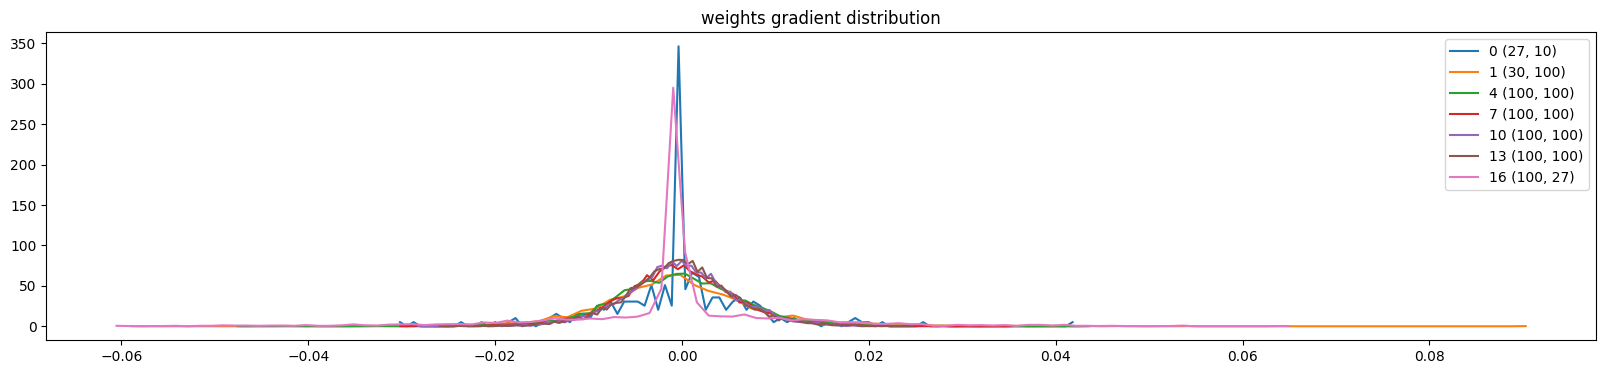

In [16]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

## Visualization 4: Update-to-Data Ratio Over Time

This is perhaps the most important diagnostic. For each parameter, we plot:
```
log10( (lr * grad).std() / data.std() )
```

This ratio measures: **how big is the update relative to the parameter's magnitude?**

**The rule of thumb:** This ratio should be around **1e-3** (i.e., `log10 = -3`, shown as the black line on the plot).
- **Too high (> 1e-2):** Updates are too aggressive — the parameter is changing too fast, training is unstable. Reduce the learning rate.
- **Too low (< 1e-4):** Updates are too small — the parameter is barely changing, training is too slow. Increase the learning rate.

This visualization helps you diagnose whether your learning rate is appropriate for each layer individually — some layers might need different learning rates (though in practice, BatchNorm helps equalize things).

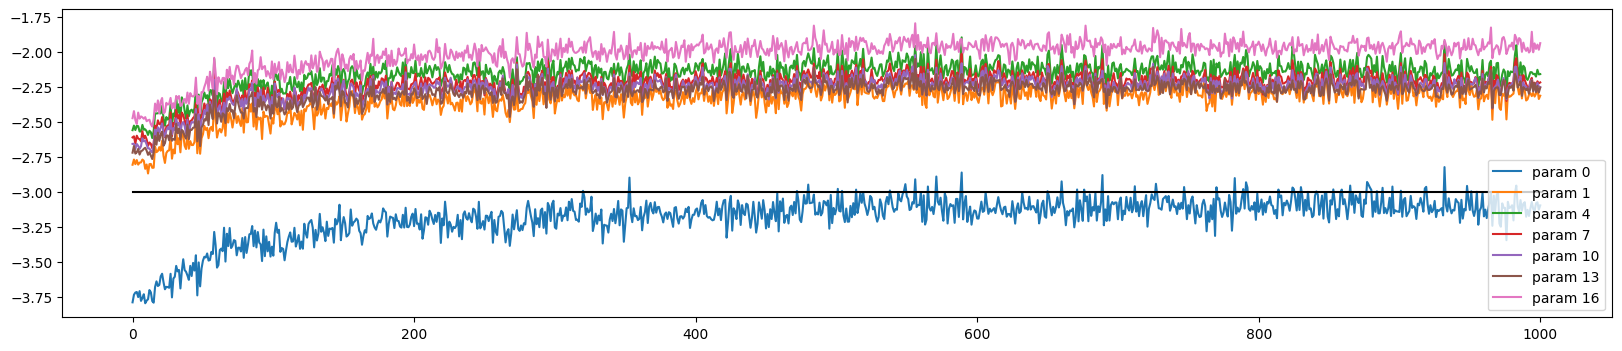

In [17]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);


## Final Evaluation and Sampling

We put all layers into **eval mode** (`layer.training = False`) so BatchNorm uses running statistics instead of batch statistics. Then evaluate on train and val sets.

**Important:** Always remember to switch between training and eval mode! Forgetting this is a very common bug with BatchNorm — your model will behave differently during training and inference if you forget.

In [18]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

# put layers into eval mode
for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')

train 2.4002976417541504
val 2.3982467651367188


## Sampling from the Model

Generate names using the trained deeper network. The forward pass now goes through all 6 layers. Since we're in eval mode, BatchNorm uses the running statistics, so generation is deterministic (given the same seed).

In [19]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      x = emb.view(emb.shape[0], -1) # concatenate the vectors
      for layer in layers:
        x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

carpah.
qarlileif.
jmrix.
thty.
sacansa.
jazhnte.
dpn.
arciigqeiunellaia.
chriiv.
kalein.
dhlm.
join.
qhinn.
sroin.
arian.
quiqaelogiearyxix.
kaeklinsan.
ed.
ecoia.
gtleley.


## Bonus Content: Interactive Visualizations

The following cells contain bonus material not covered in the video — interactive widgets and experiments to build deeper intuition about BatchNorm and gradient flow in linear layers.

In [20]:
# DONE; BONUS content below, not covered in video

interactive(children=(FloatSlider(value=0.0, description='x0', max=30.0, min=-30.0, step=0.5), Output()), _dom…

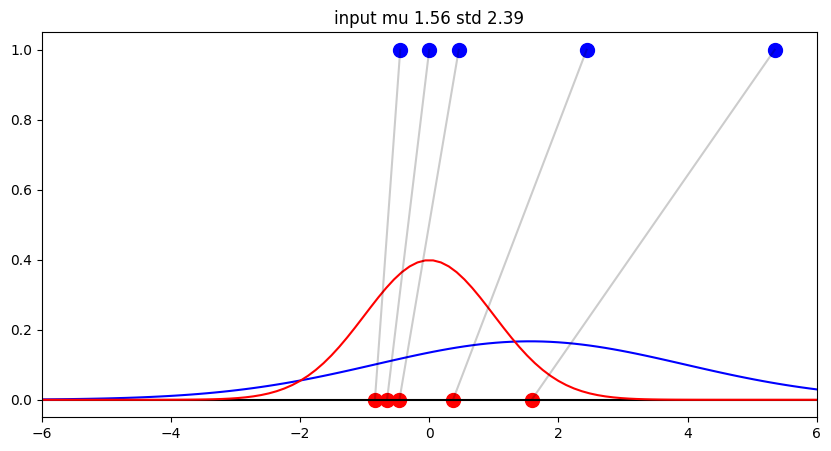

In [21]:
# BatchNorm forward pass as a widget

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import scipy.stats as stats
import numpy as np

def normshow(x0):
  
  g = torch.Generator().manual_seed(2147483647+1)
  x = torch.randn(5, generator=g) * 5
  x[0] = x0 # override the 0th example with the slider
  mu = x.mean()
  sig = x.std()
  y = (x - mu)/sig

  plt.figure(figsize=(10, 5))
  # plot 0
  plt.plot([-6,6], [0,0], 'k')
  # plot the mean and std
  xx = np.linspace(-6, 6, 100)
  plt.plot(xx, stats.norm.pdf(xx, mu, sig), 'b')
  xx = np.linspace(-6, 6, 100)
  plt.plot(xx, stats.norm.pdf(xx, 0, 1), 'r')
  # plot little lines connecting input and output
  for i in range(len(x)):
    plt.plot([x[i],y[i]], [1, 0], 'k', alpha=0.2)
  # plot the input and output values
  plt.scatter(x.data, torch.ones_like(x).data, c='b', s=100)
  plt.scatter(y.data, torch.zeros_like(y).data, c='r', s=100)
  plt.xlim(-6, 6)
  # title
  plt.title('input mu %.2f std %.2f' % (mu, sig))

interact(normshow, x0=(-30,30,0.5));


In [22]:
# Linear: activation statistics of forward and backward pass

g = torch.Generator().manual_seed(2147483647)

a = torch.randn((1000,1), requires_grad=True, generator=g)          # a.grad = b.T @ c.grad
b = torch.randn((1000,1000), requires_grad=True, generator=g)       # b.grad = c.grad @ a.T
c = b @ a
loss = torch.randn(1000, generator=g) @ c
a.retain_grad()
b.retain_grad()
c.retain_grad()
loss.backward()
print('a std:', a.std().item())
print('b std:', b.std().item())
print('c std:', c.std().item())
print('-----')
print('c grad std:', c.grad.std().item())
print('a grad std:', a.grad.std().item())
print('b grad std:', b.grad.std().item())

a std: 0.9875972270965576
b std: 1.0006722211837769
c std: 31.01241683959961
-----
c grad std: 0.9782556295394897
a grad std: 30.8818302154541
b grad std: 0.9666601419448853


In [23]:
# Linear + BatchNorm: activation statistics of forward and backward pass

g = torch.Generator().manual_seed(2147483647)

n = 1000
# linear layer ---
inp = torch.randn(n, requires_grad=True, generator=g)
w = torch.randn((n, n), requires_grad=True, generator=g) # / n**0.5
x = w @ inp
# bn layer ---
xmean = x.mean()
xvar = x.var()
out = (x - xmean) / torch.sqrt(xvar + 1e-5)
# ----
loss = out @ torch.randn(n, generator=g)
inp.retain_grad()
x.retain_grad()
w.retain_grad()
out.retain_grad()
loss.backward()

print('inp std: ', inp.std().item())
print('w std: ', w.std().item())
print('x std: ', x.std().item())
print('out std: ', out.std().item())
print('------')
print('out grad std: ', out.grad.std().item())
print('x grad std: ', x.grad.std().item())
print('w grad std: ', w.grad.std().item())
print('inp grad std: ', inp.grad.std().item())

inp std:  0.9875972270965576
w std:  1.0006722211837769
x std:  31.01241683959961
out std:  1.0
------
out grad std:  0.9782556295394897
x grad std:  0.031543977558612823
w grad std:  0.031169468536973
inp grad std:  0.9953053593635559
